# 2025 NFL Fantasy Football — Season Review (PPR)

Built on **nflreadpy** (nflverse), running against the `nfl_research` package in this repo.
The heavy lifting lives in `src/nfl_research/`; this notebook is the presentation layer, so
anything you want to reuse in a script belongs in a module rather than in a cell here.

**What you get**
1. Top **250 overall PPR finishers** for the 2025 regular season.
2. Points per game in all three scoring formats, plus efficiency (points per touch/opportunity, catch rate, YPC/YPR/YPT, aDOT).
3. Weekly **consistency** — floor, ceiling, volatility, boom/bust rates, startable-week rate.
4. **Value over replacement** and gap-based **tiers** for a 12-team league.
5. CSV export to a folder you choose, shaped for Google Sheets Tables.

---

### What changed from the `nfl_data_py` version

| Then | Now |
|---|---|
| `nfl.import_weekly_data([2025])` | `nfl.load_player_stats(2025, summary_level="week")` |
| Hand-rolled `groupby().sum()` for season totals | `summary_level="reg"` — nflverse aggregates server-side |
| pandas throughout | nflreadpy returns **Polars**; converted to pandas once, in `loaders.py` |
| `recent_team`, `interceptions`, `sacks` | `team`, `passing_interceptions`, `sacks_suffered` |
| Offense-only weekly file | One file with **every** position — K, OL, DL included, so filtering matters |

Column renames are absorbed by `nfl_research.schema`, which maps canonical names onto whatever
the loaded file actually uses. When nflverse renames something again, add one alias there.

## 1. Setup

In [2]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Only needed if you have not run `pip install -e .` in the repo root.
REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(REPO_ROOT / 'src'))

from nfl_research import Settings, build_season, schema, to_export_map
from nfl_research import exports, loaders, metrics, rankings
from nfl_research.config import POS_COLORS

pd.set_option('display.max_columns', 250)
pd.set_option('display.width', 220)
pd.set_option('display.float_format', lambda v: f'{v:,.2f}')

settings = Settings(
    season=2025,
    top_n=250,          # board depth
    min_games=4,        # qualifier for per-game ranks
)
settings.export_dir = REPO_ROOT / 'data' / 'exports'

print(f'season      : {settings.season}')
print(f'board depth : {settings.top_n}')
print(f'positions   : {", ".join(settings.positions)}')
print(f'export dir  : {settings.export_dir}')

season      : 2025
board depth : 250
positions   : QB, RB, WR, TE, FB
export dir  : c:\Users\user\repos\nfl_research_2026\data\exports


## 2. Load and sanity-check the schema

nflreadpy caches downloads itself, so re-running this is cheap after the first call.
The schema report is worth a glance whenever nflverse ships an update — anything marked
`MISSING` means an alias needs adding in `nfl_research/schema.py`.

In [3]:
weekly = loaders.load_weekly(settings.season, season_type='REG', positions=settings.positions)
season_totals = loaders.load_season_totals(settings.season, summary_level='reg',
                                           positions=settings.positions)

print(f'weekly rows      : {len(weekly):,}')
print(f'weeks present    : {weekly["week"].min()}-{weekly["week"].max()}')
print(f'season-total rows: {len(season_totals):,}')
print(f'players          : {weekly["player_id"].nunique():,}')

weekly rows      : 6,108
weeks present    : 1-18
season-total rows: 616
players          : 616


In [4]:
report = schema.report(weekly)
missing = report[report['status'] == 'MISSING']
print(f"{len(report) - len(missing)} of {len(report)} canonical columns resolved")
missing if len(missing) else report.head(12)

43 of 50 canonical columns resolved


,canonical,source_column,status
10,games,,MISSING
16,sacks_taken,,MISSING
21,passing_yac,,MISSING
23,passing_2pt,,MISSING
31,rushing_2pt,,MISSING
40,receiving_yac,,MISSING
42,receiving_2pt,,MISSING


## 3. Build the boards

One call does the whole pipeline: games played, scoring formats, volume, efficiency,
weekly consistency, ranks, value over replacement, and tiers.

In [5]:
boards = build_season(settings, weekly, season_totals)

overall  = boards['overall']
top250   = boards['top_n']
game_log = boards['game_log']

assert len(top250) >= 250, f'only {len(top250)} players available'

print(f'{len(overall):,} qualifying players | board depth {len(top250)}')
print(f'PPR points at rank {len(top250)}: {top250["points_ppr"].iloc[-1]:.1f}')
print()
print(top250['position'].value_counts().to_string())
print()
print(boards['replacement'].to_string(index=False))

616 qualifying players | board depth 250
PPR points at rank 250: 59.5

position
WR    98
RB    64
TE    46
QB    42

position  replacement_rank  replacement_ppg
      QB                12            17.47
      RB                30            10.93
      WR                42            10.60
      TE                12            10.58


In [6]:
top250.head(25)[['rank_ppr', 'player_name', 'pos_label', 'team', 'games',
                 'points_ppr', 'ppg_ppr', 'floor', 'ceiling',
                 'starter_week_rate', 'vorp_total', 'tier']]

,rank_ppr,player_name,pos_label,team,games,points_ppr,ppg_ppr,floor,ceiling,starter_week_rate,vorp_total,tier
0,1,Christian McCaffrey,RB1,SF,17,416.60,24.51,14.10,34.62,0.94,230.80,1.00
1,2,Puka Nacua,WR1,LA,16,375.00,23.44,13.75,35.85,0.94,205.40,1.00
2,3,Bijan Robinson,RB2,ATL,17,370.80,21.81,8.56,32.50,0.82,185.00,2.00
3,4,Jahmyr Gibbs,RB3,DET,17,366.90,21.58,7.06,37.48,0.71,181.10,2.00
4,5,Josh Allen,QB1,BUF,16,364.62,22.79,9.97,38.30,0.62,85.03,1.00
5,6,Jonathan Taylor,RB4,IND,17,362.30,21.31,8.24,35.48,0.82,176.50,2.00
6,7,Jaxon Smith-Njigba,WR2,SEA,17,359.90,21.17,13.84,28.94,0.94,179.70,2.00
7,8,Drake Maye,QB2,NE,17,351.96,20.70,15.62,26.68,0.59,54.90,2.00
8,9,Matthew Stafford,QB3,LA,17,350.38,20.61,12.30,27.39,0.59,53.32,2.00
9,10,Trevor Lawrence,QB4,JAX,17,338.18,19.89,10.12,28.21,0.65,41.12,2.00


## 4. Positional views

In [7]:
for pos in ['QB', 'RB', 'WR', 'TE']:
    print(f'{pos:<3} {len(boards[pos]):>4} rows')
print(f'FLEX {len(boards["flex"]):>3} rows')

boards['RB'].head(15)[['pos_label', 'player_name', 'team', 'games', 'points_ppr',
                       'ppg_ppr', 'opp_pg', 'pts_per_opp', 'boom_rate', 'tier']]

QB    40 rows
RB    90 rows
WR   110 rows
TE    50 rows
FLEX 200 rows


,pos_label,player_name,team,games,points_ppr,ppg_ppr,opp_pg,pts_per_opp,boom_rate,tier
0,RB1,Christian McCaffrey,SF,17,416.60,24.51,25.88,0.95,0.71,1.00
1,RB2,Bijan Robinson,ATL,17,370.80,21.81,22.94,0.95,0.53,2.00
2,RB3,Jahmyr Gibbs,DET,17,366.90,21.58,19.82,1.09,0.41,2.00
3,RB4,Jonathan Taylor,IND,17,362.30,21.31,22.24,0.96,0.41,2.00
4,RB5,De'Von Achane,MIA,16,322.80,20.18,20.19,1.00,0.31,2.00
5,RB6,James Cook,BUF,17,302.20,17.78,20.53,0.87,0.53,3.00
6,RB7,Chase Brown,CIN,17,282.60,16.62,18.82,0.88,0.18,3.00
7,RB8,Derrick Henry,BAL,17,279.50,16.44,19.29,0.85,0.29,3.00
8,RB9,Kyren Williams,LA,17,263.30,15.49,18.18,0.85,0.18,3.00
9,RB10,Travis Etienne,JAX,17,253.90,14.94,18.35,0.81,0.18,3.00


In [8]:
# Per-game production that ran well ahead of the season-long finish (missed time).
boards['gainers']

,player_name,pos_label,team,games,points_ppr,rank_ppr,ppg_ppr,rank_ppg,rank_delta
0,Malik Nabers,WR101,NYG,4,57.10,256,14.28,59.00,197.00
1,Tyreek Hill,WR104,MIA,4,53.50,265,13.38,69.00,196.00
2,Malik Willis,QB43,GB,4,51.18,273,12.79,78.00,195.00
3,Kyler Murray,QB38,ARI,5,77.78,212,15.56,42.00,170.00
4,Carson Wentz,QB39,MIN,5,70.34,226,14.07,63.00,163.00
5,Davis Mills,QB41,HOU,6,68.60,231,11.43,107.00,124.00
6,Jayden Daniels,QB34,WAS,7,114.28,156,16.33,34.00,122.00
7,Garrett Wilson,WR62,NYJ,7,99.50,173,14.21,60.00,113.00
8,Cam Skattebo,RB37,NYG,8,127.70,135,15.96,37.00,98.00
9,Tucker Kraft,TE24,GB,8,117.20,151,14.65,53.00,98.00


## 5. Charts

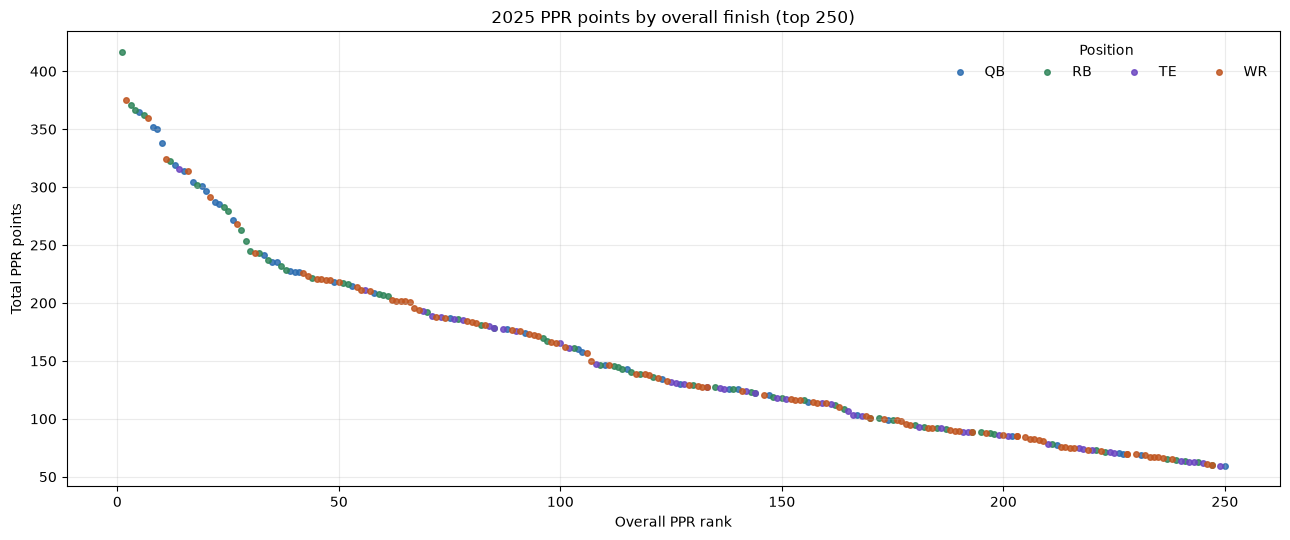

In [9]:
fig, ax = plt.subplots(figsize=(13, 5.5))
for pos, grp in top250.groupby('position'):
    ax.scatter(grp['rank_ppr'], grp['points_ppr'], s=16,
               color=POS_COLORS.get(pos, '#999'), label=pos, alpha=0.85)
ax.set(title=f'{settings.season} PPR points by overall finish (top {settings.top_n})',
       xlabel='Overall PPR rank', ylabel='Total PPR points')
ax.legend(title='Position', frameon=False, ncols=5)
ax.grid(alpha=0.25)
plt.tight_layout(); plt.show()

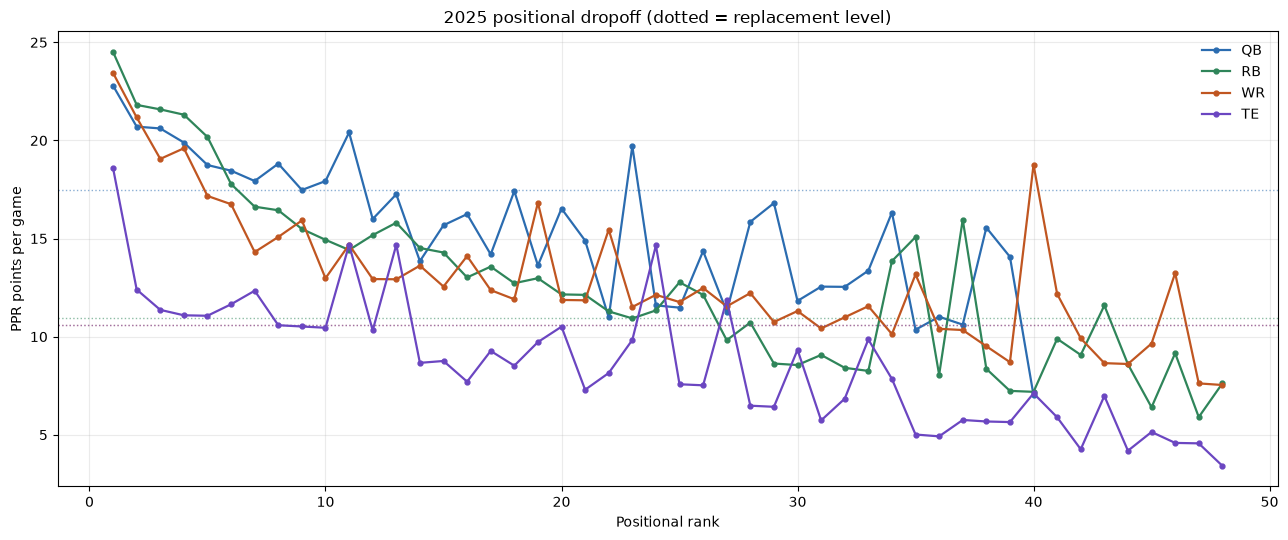

In [10]:
levels = dict(zip(boards['replacement']['position'], boards['replacement']['replacement_ppg']))

fig, ax = plt.subplots(figsize=(13, 5.5))
for pos in ['QB', 'RB', 'WR', 'TE']:
    grp = boards[pos][boards[pos]['ppg_ppr'].notna()].head(48)
    ax.plot(grp['pos_rank'], grp['ppg_ppr'], marker='o', ms=3.5, lw=1.6,
            color=POS_COLORS[pos], label=pos)
    ax.axhline(levels.get(pos), color=POS_COLORS[pos], ls=':', lw=1, alpha=0.55)
ax.set(title=f'{settings.season} positional dropoff (dotted = replacement level)',
       xlabel='Positional rank', ylabel='PPR points per game')
ax.legend(frameon=False)
ax.grid(alpha=0.25)
plt.tight_layout(); plt.show()

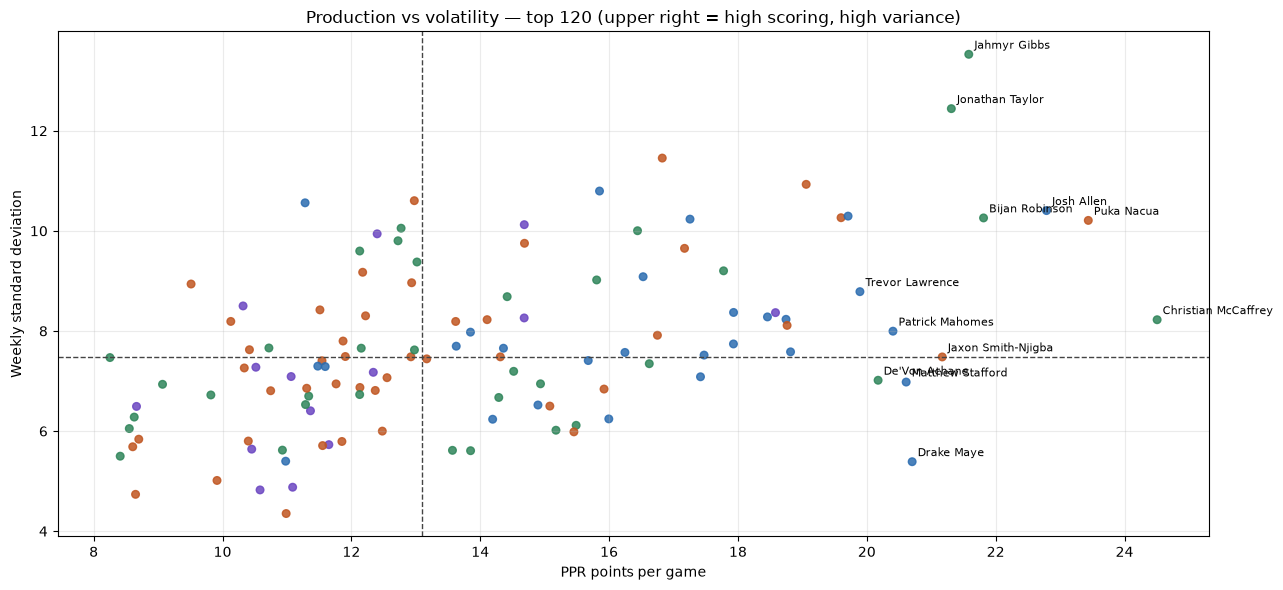

In [11]:
sub = top250[top250['games'] >= settings.min_games].head(120)

fig, ax = plt.subplots(figsize=(13, 6))
ax.scatter(sub['ppg_ppr'], sub['stdev'], s=30,
           c=sub['position'].map(POS_COLORS).fillna('#999'), alpha=0.85)
ax.axvline(sub['ppg_ppr'].median(), color='#444', ls='--', lw=1)
ax.axhline(sub['stdev'].median(), color='#444', ls='--', lw=1)
for _, row in sub.nlargest(12, 'ppg_ppr').iterrows():
    ax.annotate(row['player_name'], (row['ppg_ppr'], row['stdev']),
                fontsize=8, xytext=(4, 4), textcoords='offset points')
ax.set(title='Production vs volatility — top 120 (upper right = high scoring, high variance)',
       xlabel='PPR points per game', ylabel='Weekly standard deviation')
ax.grid(alpha=0.25)
plt.tight_layout(); plt.show()

## 6. Export

`settings.export_dir` is the default destination. To pick a folder interactively, run
`settings.export_dir = exports.choose_export_folder(settings.export_dir)` — it tries a native
folder dialog first and falls back to a typed path.

In [12]:
export_map = to_export_map(boards, settings)

for filename, frame in export_map.items():
    print(f'  {filename:<44} {len(frame):>6,} rows x {frame.shape[1]:>3} cols')

  2025_overall_top250_ppr.csv                     250 rows x  79 cols
  2025_flex_top200.csv                            200 rows x  80 cols
  2025_qb_rankings.csv                             40 rows x  79 cols
  2025_rb_rankings.csv                             90 rows x  79 cols
  2025_wr_rankings.csv                            110 rows x  79 cols
  2025_te_rankings.csv                             50 rows x  79 cols
  2025_weekly_game_log_top250.csv               3,592 rows x  20 cols
  2025_full_season_all_players.csv                616 rows x  79 cols


In [ ]:
harris_ranks = pd.read_csv('C:/Users/user/Downloads/big board - harris_football ranks.csv')


In [22]:
merged_ranks = pd.merge(harris_ranks, top250, left_on=["name"], right_on=["player_name"], how="outer")
merged_ranks.to_csv('C:/Users/user/Downloads/big_board_8_16.csv', index=False)

In [13]:
# settings.export_dir = exports.choose_export_folder(settings.export_dir)   # prompt
paths = exports.export_all(export_map, settings.export_dir)
print(f'\n{len(paths)} files written to {settings.export_dir}')

   250 rows  ->  C:\Users\user\repos\nfl_research_2026\data\exports\2025_overall_top250_ppr.csv
   200 rows  ->  C:\Users\user\repos\nfl_research_2026\data\exports\2025_flex_top200.csv
    40 rows  ->  C:\Users\user\repos\nfl_research_2026\data\exports\2025_qb_rankings.csv
    90 rows  ->  C:\Users\user\repos\nfl_research_2026\data\exports\2025_rb_rankings.csv
   110 rows  ->  C:\Users\user\repos\nfl_research_2026\data\exports\2025_wr_rankings.csv
    50 rows  ->  C:\Users\user\repos\nfl_research_2026\data\exports\2025_te_rankings.csv
 3,592 rows  ->  C:\Users\user\repos\nfl_research_2026\data\exports\2025_weekly_game_log_top250.csv
   616 rows  ->  C:\Users\user\repos\nfl_research_2026\data\exports\2025_full_season_all_players.csv

8 files written to c:\Users\user\repos\nfl_research_2026\data\exports


## 7. Into Google Sheets as a Table

1. **File ▸ Import ▸ Upload** the CSV → *Insert new sheet* → separator **Comma** → leave *Convert text to numbers* checked.
2. Click any cell in the data → **Format ▸ Convert to table**. It picks up the header automatically: one header row in `A1`, no index column, no blank rows, no totals row.
3. Worth doing once it's a Table:
   * `Catch Rate`, `Boom Rate`, `Bust Rate`, `Starter Wk Rate`, `Comp %`, `Target Share (Avg)`, `Sack Rate` export as decimals — set them to **Format ▸ Number ▸ Percent**.
   * Color scale on `PPR PPG` or `VORP Total` for an instant heat map.
   * `Data ▸ Group columns` to collapse the raw box-score block.
4. Re-running the export overwrites the same filenames, so refreshing is just: rebuild, re-import over the sheet.

## Appendix — multi-season and going Polars-native

`loaders.load_weekly` and `load_season_totals` both take a list of seasons, so historical work is
the same call with a wider range. Note that pre-2024 seasons come from the same rebuilt
nflverse stats file, so the schema is consistent all the way back — one of the real wins over
the old `nfl_data_py` layout.

In [14]:
# YEARS = [2021, 2022, 2023, 2024, 2025]
# hist = loaders.load_season_totals(YEARS, summary_level='reg', positions=settings.positions)
# (hist.pivot_table(index='player_name', columns='season',
#                   values='fantasy_points_ppr', aggfunc='max')
#      .sort_values(YEARS[-1], ascending=False)
#      .head(25))

In [15]:
# Everything above is pandas because the conversion happens once, in loaders.py.
# To work in Polars instead, skip the loader and go straight to nflreadpy:
#
# import nflreadpy as nfl, polars as pl
# wk = nfl.load_player_stats(2025, summary_level='week')
# (wk.filter(pl.col('season_type') == 'REG')
#    .group_by('player_display_name')
#    .agg(pl.col('fantasy_points_ppr').sum().alias('ppr'),
#         pl.len().alias('games'))
#    .with_columns((pl.col('ppr') / pl.col('games')).alias('ppg'))
#    .sort('ppr', descending=True)
#    .head(25))